In [2]:
import os
import sys

# 현재 작업 디렉토리 확인해보고
print("CWD:", os.getcwd())

# notebooks/ 에서 한 단계 위(프로젝트 루트)로 올라가기
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
print("PROJECT_ROOT:", PROJECT_ROOT)

# sys.path 에 프로젝트 루트가 없으면 추가
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print("Added to sys.path")


CWD: c:\Users\heeky\OneDrive\바탕 화면\sva\scalp-vision-agent\notebooks
PROJECT_ROOT: c:\Users\heeky\OneDrive\바탕 화면\sva\scalp-vision-agent
Added to sys.path


In [3]:
import pandas as pd
from pathlib import Path

from src.config import PROCESSED_DIR

eda_path = PROCESSED_DIR / "eda_table.csv"
df = pd.read_csv(eda_path)

df.shape, df.head()


((91156, 14),
                                  sample_id  split location gender  age  \
 0  0013_A2LEBJJDE00060O_1606550825417_3_TH  train       TH      F   40   
 1  0177_A2LEBJJDE00152B_1604650530904_6_BH  train       BH      F   70   
 2  0335_A2LEBJJDE00013X_1602916465540_6_BH  train       BH      F   40   
 3  0335_A2LEBJJDE000542_1605676381132_4_LH  train       LH      M   30   
 4  0425_A2LEBJJDE00079P_1605793927978_5_RH  train       RH      F   70   
 
   shampoo_frequency perm_frequency dye_frequency  value_1  value_2  value_3  \
 0             1일 1회         1~3회/연        1~3회/연        0        0        0   
 1             1일 1회           하지않음          하지않음        0        0        0   
 2             1일 1회         1~3회/연        4~6회/연        0        0        0   
 3             1일 1회           하지않음          하지않음        0        0        0   
 4             1일 1회        7회 이상/연          하지않음        0        0        0   
 
    value_4  value_5  value_6  
 0        0        0

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91156 entries, 0 to 91155
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   sample_id          91156 non-null  object
 1   split              91156 non-null  object
 2   location           91156 non-null  object
 3   gender             91156 non-null  object
 4   age                91156 non-null  int64 
 5   shampoo_frequency  91151 non-null  object
 6   perm_frequency     91156 non-null  object
 7   dye_frequency      91156 non-null  object
 8   value_1            91156 non-null  int64 
 9   value_2            91156 non-null  int64 
 10  value_3            91156 non-null  int64 
 11  value_4            91156 non-null  int64 
 12  value_5            91156 non-null  int64 
 13  value_6            91156 non-null  int64 
dtypes: int64(7), object(7)
memory usage: 9.7+ MB


In [5]:
df.isna().mean().sort_values(ascending=False)


shampoo_frequency    0.000055
sample_id            0.000000
split                0.000000
location             0.000000
gender               0.000000
age                  0.000000
perm_frequency       0.000000
dye_frequency        0.000000
value_1              0.000000
value_2              0.000000
value_3              0.000000
value_4              0.000000
value_5              0.000000
value_6              0.000000
dtype: float64

In [6]:
# 탈모 등급 분포
df["value_6"].value_counts().sort_index()


value_6
0    67570
1    17549
2     4959
3     1078
Name: count, dtype: int64

In [9]:
for col in ["value_1", "value_2", "value_3", "value_4", "value_5"]:
    print(f"=== {col} 분포 ===")
    print(df[col].value_counts().sort_index())
    print()


=== value_1 분포 ===
value_1
0    75452
1     5702
2     7062
3     2940
Name: count, dtype: int64

=== value_2 분포 ===
value_2
0    18136
1    36193
2    31945
3     4882
Name: count, dtype: int64

=== value_3 분포 ===
value_3
0    29561
1    39217
2    16859
3     5519
Name: count, dtype: int64

=== value_4 분포 ===
value_4
0    86907
1     2841
2      981
3      427
Name: count, dtype: int64

=== value_5 분포 ===
value_5
0    54551
1    21415
2    12287
3     2903
Name: count, dtype: int64



In [10]:
(
    df
    .groupby("shampoo_frequency")["value_6"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
)


,count,mean
shampoo_frequency,,
1일 1회,66873,0.336608
1일 2회,15669,0.308124
2일 1회,8609,0.390638


In [15]:
import matplotlib.pyplot as plt

# matplotlib 한글 폰트 설정 (필요시)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 기준
# plt.rcParams['font.family'] = 'AppleGothic' # Mac 기준
plt.rcParams['axes.unicode_minus'] = False # 음수 부호 깨짐 방지

In [12]:
import seaborn as sns

sns.set(style="whitegrid")


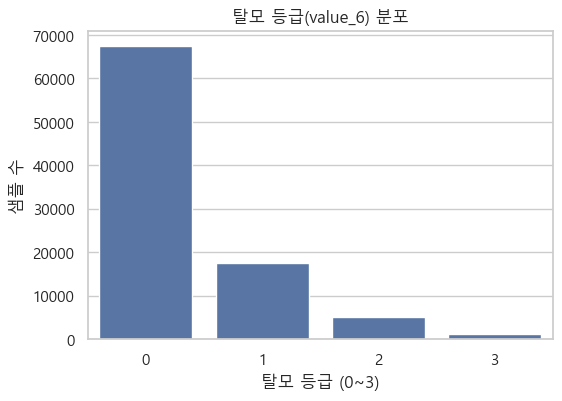

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(x="value_6", data=df)
plt.title("탈모 등급(value_6) 분포")
plt.xlabel("탈모 등급 (0~3)")
plt.ylabel("샘플 수")
plt.show()


In [17]:
# 샴푸 빈도별 value_6 평균 계산
shampoo_stats = (
    df
    .groupby("shampoo_frequency")["value_6"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
)

display(shampoo_stats.head(10))


,count,mean
shampoo_frequency,,
1일 1회,66873,0.336608
1일 2회,15669,0.308124
2일 1회,8609,0.390638


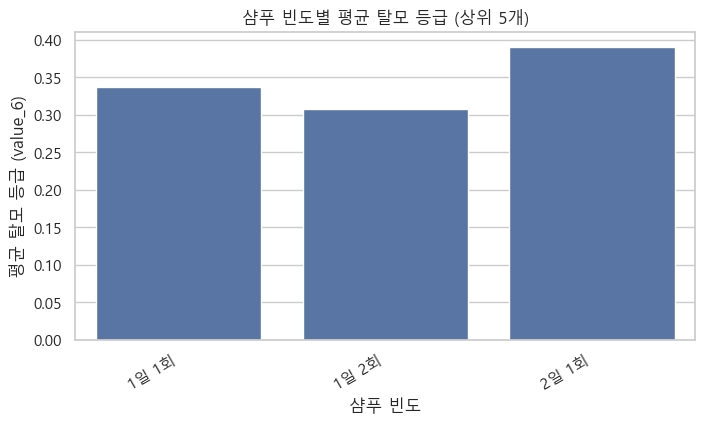

In [18]:
top_shampoo = shampoo_stats.head(5).reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(
    data=top_shampoo,
    x="shampoo_frequency",
    y="mean"
)
plt.title("샴푸 빈도별 평균 탈모 등급 (상위 5개)")
plt.xlabel("샴푸 빈도")
plt.ylabel("평균 탈모 등급 (value_6)")
plt.xticks(rotation=30, ha="right")
plt.show()


C:\Users\heeky\AppData\Local\Temp\ipykernel_4364\2337328031.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("age_band")["value_6"]


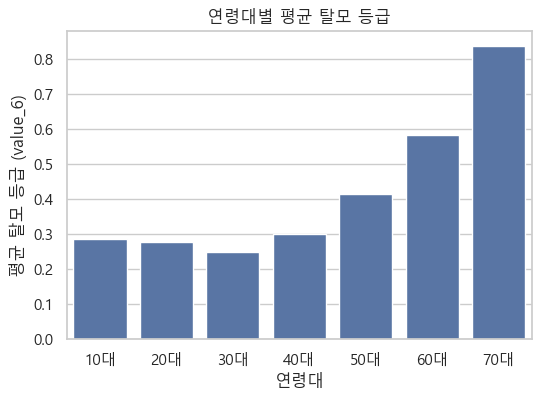

In [19]:
# age가 있는 행만 사용
df_age = df.dropna(subset=["age"]).copy()

# 10살 단위 구간화 (20~70대 가정)
age_bins = [10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ["10대", "20대", "30대", "40대", "50대", "60대", "70대"]
df_age["age_band"] = pd.cut(df_age["age"], bins=age_bins, labels=age_labels, right=False)

age_stats = (
    df_age
    .groupby("age_band")["value_6"]
    .mean()
    .dropna()
    .reset_index()
)

plt.figure(figsize=(6, 4))
sns.barplot(data=age_stats, x="age_band", y="value_6")
plt.title("연령대별 평균 탈모 등급")
plt.xlabel("연령대")
plt.ylabel("평균 탈모 등급 (value_6)")
plt.show()


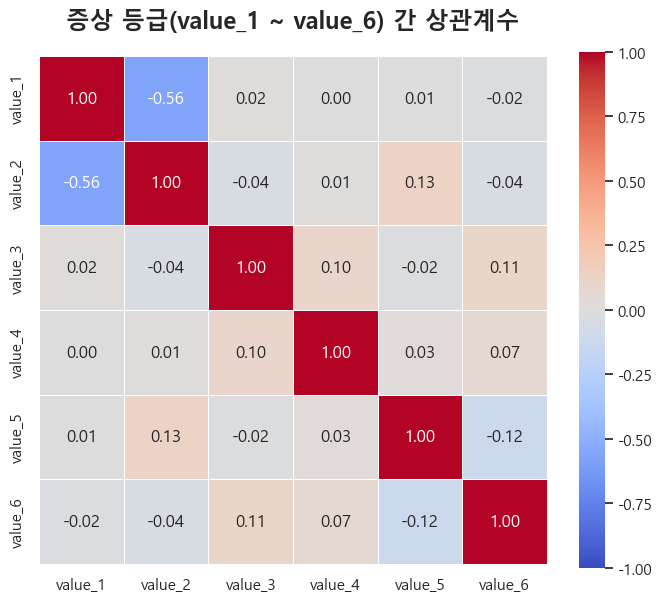

In [36]:
plt.figure(figsize=(7, 6))
sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='coolwarm',      # 이거 진짜 예뻐요!!! 강추
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.7,
            linecolor='white',
           )

plt.title("증상 등급(value_1 ~ value_6) 간 상관계수", fontsize=17, fontweight='bold', pad=20)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()